# Binary Tree Tensor Network (TTN) Born Machine — Heston Paths

This notebook trains a **Binary Tree Tensor Network (BTT)** Born machine on
Heston simulated price paths, using the same data generation and encoding as
`paper_reproduction.ipynb`.

The trained model is saved to `ttn_heston.jld2` so it can be loaded and
compared with the MPS model in a separate comparison notebook.

**Architecture recap**:
- Heap-indexed balanced binary tree with `N_pad = nextpow(2, M)` leaves
- All nodes upward-isometric (root-canonical form) before each gradient step
- Per-node Adam with cosine learning-rate schedule and validation early-stopping
- Exact ancestral sampling via sequential conditional probabilities


## 1. Environment Setup

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, "../.."))
Pkg.resolve()
Pkg.instantiate()

using MPSFast, MPSFast.Encoders
using Random, Statistics, LinearAlgebra, Printf
using Plots


  Activating project at `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl`
     Project No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Project.toml`
    Manifest No packages added to or removed from `~/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/Manifest.toml`


### TTN Visualization Helper

`plot_ttn_structure` renders the heap-indexed binary tree of any `BinaryTTN` object:

- **Red circles** — physical leaf tensors $A_j \in \mathbb{R}^{d \times \chi}$ (one per time step)
- **Grey circles** — padding leaves (bond-dim 1, fixed to $|0\rangle$)
- **Blue circles** — internal tensors $B_h \in \mathbb{R}^{\chi_l \times \chi_r \times \chi_u}$
- **Edge labels** — bond dimension $\chi$ on each leg (toggle with `show_bond_dims`)

In [2]:
"""
    plot_ttn_structure(ttn::BinaryTTN; kwargs...) → Plots.Plot

Visualise the heap-indexed binary-tree graph of a `BinaryTTN`.

# Keyword arguments
- `title_str`      : plot title (auto-generated from `ttn` fields if not supplied)
- `show_bond_dims` : annotate each edge with its bond dimension (default `true`)
- `figsize`        : `(width, height)` in pixels passed to Plots (default `(1000, 520)`)
"""
function plot_ttn_structure(
    ttn::BinaryTTN;
    title_str::String  = "TTN  (n_sites=$(ttn.n_sites), N_pad=$(ttn.N_pad), D_max=$(ttn.D_max))",
    show_bond_dims::Bool = true,
    figsize              = (1000, 520),
)
    N_pad   = ttn.N_pad
    n_sites = ttn.n_sites
    D       = Int(round(log2(N_pad)))   # tree depth (leaves at depth D from root)

    # ── 1. Compute (x, y) position for every heap node ───────────────────────
    # Leaves evenly spaced at y = 0.  Root at y = 1.
    pos = Dict{Int, NTuple{2,Float64}}()
    for j in 1:N_pad
        pos[N_pad + j - 1] = ((j - 0.5) / N_pad, 0.0)
    end
    for d in (D - 1):-1:0                     # bottom-up
        for h in 2^d : 2^(d+1) - 1
            xl = pos[2h][1];  xr = pos[2h+1][1]
            pos[h] = ((xl + xr) / 2, (D - d) / D)
        end
    end

    # ── 2. Canvas ─────────────────────────────────────────────────────────────
    p = Plots.plot(;
        title      = title_str,
        titleloc   = :center,
        titlefont  = (12, :bold),
        size       = figsize,
        framestyle = :none,
        legend     = false,
        xlims      = (-0.02, 1.02),
        ylims      = (-0.25, 1.18),
        grid       = false,
    )

    # ── 3. Draw edges (parent → children) ─────────────────────────────────────
    for h in 1:(N_pad - 1)
        xp, yp = pos[h]
        B      = ttn.internals[h]
        for (hc, χ_bond) in ((2h, size(B, 1)), (2h + 1, size(B, 2)))
            xc, yc = pos[hc]
            Plots.plot!(p, [xp, xc], [yp, yc]; color = :gray65, lw = 1.8, label = nothing)
            if show_bond_dims
                mx = (xp + xc) / 2;  my = (yp + yc) / 2
                # Perpendicular offset keeps label off the line
                dx = xc - xp;  dy = yc - yp
                ℓ  = sqrt(dx^2 + dy^2)
                ox = -(dy / ℓ) * 0.020;  oy = (dx / ℓ) * 0.020
                Plots.annotate!(p, mx + ox, my + oy,
                                Plots.text("χ=$χ_bond", 6, :gray35, :center))
            end
        end
    end

    # ── 4. Draw internal nodes (blue) ─────────────────────────────────────────
    for h in 1:(N_pad - 1)
        x, y         = pos[h]
        χ_l, χ_r, χ_u = size(ttn.internals[h])
        top_lbl      = h == 1 ? "root" : "h=$h"

        Plots.scatter!(p, [x], [y];
                       markersize        = 14,
                       markershape       = :circle,
                       markercolor       = :steelblue,
                       markerstrokecolor = :white,
                       markerstrokewidth = 2,
                       label             = nothing)
        Plots.annotate!(p, x, y + 0.075,
                        Plots.text(top_lbl, 7, :steelblue, :center, :bold))
        if show_bond_dims
            Plots.annotate!(p, x, y + 0.028,
                            Plots.text("($χ_l×$χ_r×$χ_u)", 5, :gray45, :center))
        end
    end

    # ── 5. Draw leaf nodes (red = real, grey = padding) ───────────────────────
    for j in 1:N_pad
        h         = N_pad + j - 1
        x, y      = pos[h]
        is_real   = j <= n_sites
        d_j, χ_j  = size(ttn.leaves[j])
        color     = is_real ? :tomato    : :lightgray
        lbl_color = is_real ? :firebrick : :gray55
        lbl       = is_real ? "t=$j"     : "pad"

        Plots.scatter!(p, [x], [y];
                       markersize        = 11,
                       markershape       = :circle,
                       markercolor       = color,
                       markerstrokecolor = :white,
                       markerstrokewidth = 2,
                       label             = nothing)
        Plots.annotate!(p, x, y - 0.055,
                        Plots.text(lbl, 7, lbl_color, :center, :bold))
        if show_bond_dims && is_real
            Plots.annotate!(p, x, y - 0.105,
                            Plots.text("(d=$d_j,χ=$χ_j)", 5, :gray50, :center))
        end
    end

    return p
end

plot_ttn_structure

## 2. Heston Model Simulation

Same parameters as `paper_reproduction.ipynb` for apples-to-apples comparison.

In [26]:
"""
    simulate_heston(N, M; S0, V0, κ, θ, ξ, ρ, r, dt, rng)

Generate `N` paths of `M` steps under the Heston stochastic volatility model
using a simple Euler-Maruyama discretisation.
"""
function simulate_heston(
    N::Int, M::Int;
    S0 = 100.0, V0 = 0.04, κ = 2.0, θ = 0.04,
    ξ = 0.3, ρ = -0.7, r = 0.0, dt = 1/252,
    rng = Random.default_rng(),
)
    S = Matrix{Float64}(undef, N, M)
    V = Matrix{Float64}(undef, N, M)
    for i in 1:N
        s = S0;  v = V0
        for t in 1:M
            z1 = randn(rng);  z2 = randn(rng)
            w1 = z1
            w2 = ρ * z1 + sqrt(1 - ρ^2) * z2
            v  = max(v + κ * (θ - v) * dt + ξ * sqrt(max(v, 0.0) * dt) * w2, 0.0)
            s  = s * exp((r - 0.5 * v) * dt + sqrt(max(v, 0.0) * dt) * w1)
            S[i, t] = s
            V[i, t] = v
        end
    end
    return S, V
end

rng     = MersenneTwister(2024)
N_train = 10_000
M       = 8

paths, paths_ν = simulate_heston(N_train, M; rng = rng)
println("Heston paths: ", size(paths))
println("Mean S[M]  : ", round(mean(paths[:, M]), digits=2))
println("Std  S[M]  : ", round(std(paths[:, M]),  digits=2))


Heston paths: (10000, 8)
Mean S[M]  : 99.65
Std  S[M]  : 3.57


## 3. Encode with BasisEncoder

In [27]:
m   = 4    # local dimension d = 2^m = 16 buckets per timestep
enc = BasisEncoder(m)
fit_grid!(enc, paths)
xi  = encode_paths(enc, paths)

encoder_summary(enc, M, 200)
println("xi range: ", extrema(xi))
println("d = $(site_dim(enc)),  M = $M")


xi range: (1, 16)
d = 16,  M = 8


┌ Info: Encoder
│   encoder = BasisEncoder
│   M = 8
│   chain_length = 8
│   site_dim = 16
│   D_max = 200
│   params = 3846400
└ @ MPSFast.Encoders /Users/bi006881/dev/Notes on Time Series Generation for Options Pricing/repos/MPSFast.jl/src/Encoders.jl:414


## 4. Train TTN

Key hyperparameters are chosen to be **comparable** to the MPS run:
- Same bond dimension `D_max`
- Same number of epochs and learning rate
- Same validation split and early-stopping patience


In [28]:
D_max_ttn = 64        # TTN bonds saturate faster than MPS; 64 is comparable to MPS χ=150
n_epochs  = 200
η         = 5e-4

# ── Validation split (10 %) ────────────────────────────────────────────────
val_frac  = 0.10
N_total   = size(xi, 1)
N_val     = round(Int, val_frac * N_total)
perm      = randperm(MersenneTwister(0), N_total)
xi_val    = xi[perm[1:N_val],        :]
xi_tr     = xi[perm[N_val+1:end],    :]
println("Train: $(size(xi_tr,1)) paths   Val: $(size(xi_val,1)) paths")

# ── Initialise TTN ─────────────────────────────────────────────────────────
ttn = init_ttn(M, site_dim(enc), D_max_ttn; T = Float32, rng = MersenneTwister(1))
println("TTN: n_sites=$(ttn.n_sites), N_pad=$(ttn.N_pad), D_max=$(ttn.D_max)")
println("     leaves:    ", [size(ttn.leaves[j]) for j in 1:ttn.N_pad if ttn.d_vec[j] > 1])
println("     internals: ", [size(ttn.internals[i]) for i in 1:ttn.N_pad-1])

# ── Train ──────────────────────────────────────────────────────────────────
ttn_val_nll = Float64[]
ttn_nll_hist = train_ttn!(
    ttn, xi_tr, n_epochs, η, D_max_ttn;
    verbose          = true,
    nll_samples      = 5_000,
    lr_schedule      = cosine_lr,
    val_data         = xi_val,
    val_samples      = 2_000,
    patience         = 15,
    val_nll_log      = ttn_val_nll,
)


Train: 9000 paths   Val: 1000 paths
TTN: n_sites=8, N_pad=8, D_max=64
     leaves:    [(16, 16), (16, 16), (16, 16), (16, 16), (16, 16), (16, 16), (16, 16), (16, 16)]
     internals: [(64, 64, 1), (64, 64, 64), (64, 64, 64), (16, 16, 64), (16, 16, 64), (16, 16, 64), (16, 16, 64)]
train_ttn!: n_sites=8, N_pad=8, D_max=64, epochs=200
Epoch 1/200 | TTN NLL ≈ 22.6039 | η=0.0005 | 3.35 s
  ↳ val NLL ≈ 22.8466  (patience 0/15)
Epoch 2/200 | TTN NLL ≈ 22.0276 | η=0.0005 | 3.18 s
  ↳ val NLL ≈ 22.3415  (patience 0/15)
Epoch 3/200 | TTN NLL ≈ 21.5365 | η=0.0005 | 2.84 s
  ↳ val NLL ≈ 21.8362  (patience 0/15)
Epoch 4/200 | TTN NLL ≈ 21.2672 | η=0.0005 | 2.65 s
  ↳ val NLL ≈ 21.5594  (patience 0/15)
Epoch 5/200 | TTN NLL ≈ 21.0156 | η=0.0005 | 2.79 s
  ↳ val NLL ≈ 21.2934  (patience 0/15)
Epoch 6/200 | TTN NLL ≈ 20.7853 | η=0.000499 | 2.71 s
  ↳ val NLL ≈ 21.089  (patience 0/15)
Epoch 7/200 | TTN NLL ≈ 20.5898 | η=0.000499 | 2.76 s
  ↳ val NLL ≈ 20.9426  (patience 0/15)
Epoch 8/200 | TTN NLL ≈ 20

200-element Vector{Float64}:
 22.60390432267065
 22.027603304224126
 21.536522116669218
 21.267180025531868
 21.015565976552452
 20.785287373380065
 20.58975624510405
 20.330770235921367
 20.179906713004016
 20.010193010665294
  ⋮
 12.723662540761788
 12.734368745017356
 12.675147160919629
 12.648120038521165
 12.671172136054336
 12.641582487999887
 12.691981398800479
 12.69019914042496
 12.673873301916007

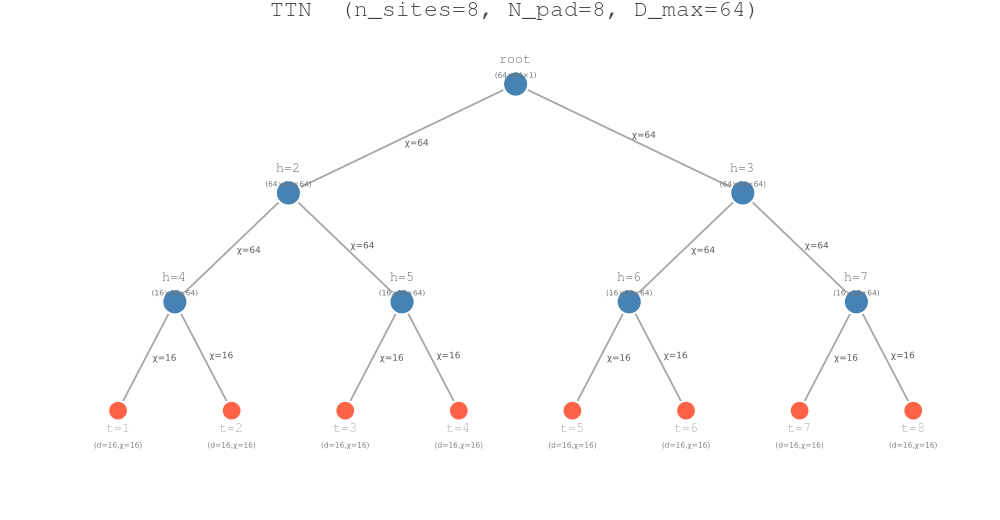

In [29]:
# ── Show TTN architecture diagram ─────────────────────────────────────────
# Visualise the trained TTN: bond dimensions reflect the truncated structure.
# Red  = physical time-step leaves (t=1…n_sites)
# Grey = padding leaves (fixed |0⟩, trivial bond dim 1)
# Blue = internal contraction nodes
plot_ttn_structure(ttn)

## 5. Training Convergence

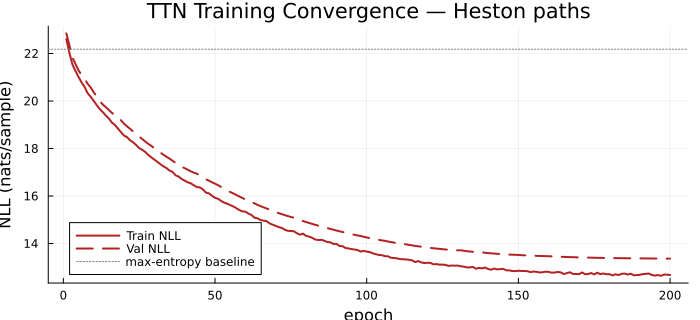

Epoch  Train-NLL  Val-NLL
1       22.6039     22.8466
2       22.0276     22.3415
3       21.5365     21.8362
4       21.2672     21.5594
5       21.0156     21.2934
6       20.7853     21.0890
7       20.5898     20.9426
8       20.3308     20.7255
9       20.1799     20.5729
10      20.0102     20.3685
11      19.8291     20.1886
12      19.6603     20.0011
13      19.5313     19.8535
14      19.3903     19.7410
15      19.2637     19.6213
16      19.0921     19.5019
17      18.9942     19.4104
18      18.8364     19.2946
19      18.6865     19.1864
20      18.5447     19.0470
21      18.4760     18.9301
22      18.3436     18.8304
23      18.2621     18.7130
24      18.1469     18.6145
25      18.0154     18.5056
26      17.9475     18.3992
27      17.8542     18.2936
28      17.7271     18.1965
29      17.6280     18.1111
30      17.5328     18.0105
31      17.4357     17.9124
32      17.3398     17.8275
33      17.2466     17.7372
34      17.1759     17.6520
35      17.0695     17

In [30]:
# NLL table
println("Epoch  Train-NLL  Val-NLL")
for e in 1:length(ttn_nll_hist)
    vv = e <= length(ttn_val_nll) ? @sprintf("%.4f", ttn_val_nll[e]) : "—"
    @printf("%-6d  %.4f     %s\n", e, ttn_nll_hist[e], vv)
end

# ── Figure: TTN training convergence ──────────────────────────────────────
p_nll = plot(1:length(ttn_nll_hist), ttn_nll_hist;
    label="Train NLL", lw=2, color=:firebrick,
    xlabel="epoch", ylabel="NLL (nats/sample)",
    title="TTN Training Convergence — Heston paths", size=(700, 320))
if !isempty(ttn_val_nll)
    plot!(p_nll, 1:length(ttn_val_nll), ttn_val_nll;
        label="Val NLL", lw=2, ls=:dash, color=:firebrick)
end
hline!(p_nll, [log(site_dim(enc)^M)];
    label="max-entropy baseline", ls=:dot, color=:grey)
display(p_nll)


## 6. Sample New Paths from TTN

In [31]:
N_samp = 5_000
ttn_paths, ttn_xi = sample_ttn(enc, ttn, N_samp; seed = 7)
println("Sampled paths shape: ", size(ttn_paths))

# ── Marginal table ─────────────────────────────────────────────────────────
println("\n  t   Heston mean  TTN mean   Heston std   TTN std")
for t in filter(t -> t <= M, [1, 5, 10, 20, 30])
    @printf("  %-3d  %9.3f   %9.3f   %9.3f   %9.3f\n", t,
            mean(paths[:,t]),     mean(ttn_paths[:,t]),
            std(paths[:,t]),      std(ttn_paths[:,t]))
end


Sampled paths shape: (5000, 8)

  t   Heston mean  TTN mean   Heston std   TTN std
  1       99.962      99.136       1.259       6.218
  5       99.765      99.060       2.827       6.289


## 7. Visualisation

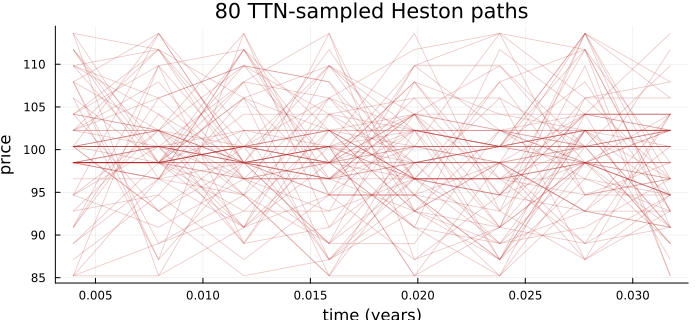

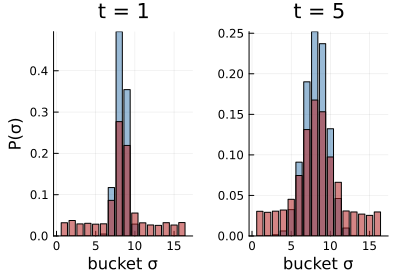

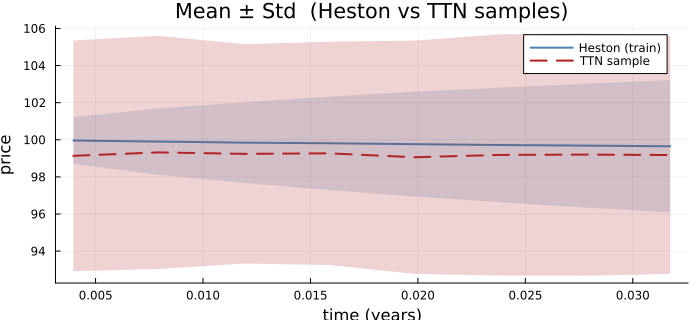

In [32]:
ts = (1:M) ./ 252

# ── Figure A: example sampled paths ───────────────────────────────────────
p_paths = plot(ts, ttn_paths[1:80, :]';
    color=:firebrick, alpha=0.25, lw=0.8, label=false,
    xlabel="time (years)", ylabel="price",
    title="80 TTN-sampled Heston paths", size=(700, 320))
display(p_paths)

# ── Figure B: marginal distributions at selected time steps ───────────────
d_enc      = site_dim(enc)
times_show = filter(t -> t <= M, [1, 5, 10, 20, 30])
train_marg = [count(==(σ), xi[:,t])     / N_train for σ in 1:d_enc, t in 1:M]
ttn_marg   = [count(==(σ), ttn_xi[:,t]) / N_samp  for σ in 1:d_enc, t in 1:M]

p_marg = plot(layout=(1, length(times_show)),
              size=(200 * length(times_show), 280),
              title=reshape(["t = $t" for t in times_show], 1, :),
              legend=false)
for (k, t) in enumerate(times_show)
    bar!(p_marg, subplot=k, 1:d_enc, train_marg[:, t];
         fillalpha=0.55, color=:steelblue, label="train",
         xlabel="bucket σ", ylabel=k==1 ? "P(σ)" : "")
    bar!(p_marg, subplot=k, 1:d_enc, ttn_marg[:, t];
         fillalpha=0.55, color=:firebrick, label="TTN")
end
display(p_marg)

# ── Figure C: per-timestep mean ± std ─────────────────────────────────────
train_μ = vec(mean(paths,     dims=1))
ttn_μ   = vec(mean(ttn_paths, dims=1))
train_σ = vec(std(paths,      dims=1))
ttn_σ   = vec(std(ttn_paths,  dims=1))

p_stats = plot(ts, train_μ; ribbon=train_σ, fillalpha=0.2,
    label="Heston (train)", color=:steelblue, lw=2,
    xlabel="time (years)", ylabel="price",
    title="Mean ± Std  (Heston vs TTN samples)", size=(700, 320))
plot!(p_stats, ts, ttn_μ; ribbon=ttn_σ, fillalpha=0.2,
    label="TTN sample", color=:firebrick, lw=2, ls=:dash)
display(p_stats)


## 8. Save TTN Bundle

Saves the trained TTN and metadata to `ttn_heston.jld2` so the comparison
notebook can load it alongside `mps_heston.jld2` without re-training.


In [33]:
using JLD2

ttn_meta = Dict{String,Any}(
    "N_train"     => N_train,
    "M"           => M,
    "m"           => m,
    "D_max"       => D_max_ttn,
    "n_epochs"    => n_epochs,
    "encoder"     => string(typeof(enc)),
    "Smin"        => enc.Smin,
    "Smax"        => enc.Smax,
)

@save "ttn_heston.jld2" ttn ttn_nll_hist ttn_val_nll ttn_meta
println("Saved → ttn_heston.jld2")

# Sanity-reload
@load "ttn_heston.jld2" ttn ttn_nll_hist ttn_val_nll ttn_meta
println("Reloaded: final train NLL = ", round(ttn_nll_hist[end]; digits=4))


Saved → ttn_heston.jld2
Reloaded: final train NLL = 12.6739
